In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from ipywidgets import interact

# <center> Wingspan data analysis

![Wingspan](https://images7.alphacoders.com/107/thumb-350-1079758.jpg)

## Raw data

In [2]:
#Display float values with two decimals in pandas:
pd.options.display.float_format = "{:,.2f}".format 

#Load data:
Flausch_data = pd.read_excel("./FlauschBirds_withBu.ods", engine="odf")
Data = pd.read_excel("./Birds_withBu.ods", engine="odf")

In [3]:
#Include some features to have a closer look at the raw data:

#A range slider can be used to chose a range of points in a certain category.
#All games where the points in the category were within the range are displayed as a table.
#A dropdown menu is included to chose the category.

print('FlauschBu Daten:')

#Create a the range slider and define the features it has:
FlauschBu_slider = widgets.IntRangeSlider(
    value=[95, 100],
    min=1,
    max=100,
    step=1,
    description='Points',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

#Create a the dropdown menu and define the features it has:
FlauschBu_dropdown = widgets.Dropdown(
    options=['Birds','Bonus','Objectives','Eggs','Cached','Tucked','Total'],
    value='Total',
    description='Category:',
    disabled=False,
)

#This function defines what happens when the slider and the dropdown menu obtain their input.
#The slider and the dropdown menu are the arguments.
#Function displays the data at alle locations where
#data[category] > smaller slider value and data[category] < larger slider value is true.

def interactive_FlauschBu(FlauschBu_slider, FlauschBu_dropdown):
    return (display(Flausch_data.loc[(Flausch_data[FlauschBu_dropdown] > FlauschBu_slider[0]) 
        & (Flausch_data[FlauschBu_dropdown] < FlauschBu_slider[1])]))

#The method interactive_output needs this control expression, that holds all widgets:
control = {'FlauschBu_slider' : FlauschBu_slider, 'FlauschBu_dropdown' : FlauschBu_dropdown}
#Now all the widgets can be placed in a box for better control over layout:
ui = widgets.VBox([widgets.HBox([FlauschBu_slider]), 
            widgets.HBox([FlauschBu_dropdown])])

#Us interactive_output by passing the function and the control expression for the widgets:
out = widgets.interactive_output(interactive_FlauschBu, control)
#Display the widgets and the output:
display(ui, out)

FlauschBu Daten:


Output()

In [4]:
#Same as before for the other data set:
print('Bu Daten:')

Bu_slider = widgets.IntRangeSlider(
    value=[95, 100],
    min=1,
    max=100,
    step=1,
    description='Points',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

Bu_dropdown = widgets.Dropdown(
    options=['Birds','Bonus','Objectives','Eggs','Cached','Tucked','Total'],
    value='Total',
    description='Category:',
    disabled=False,
)

def interactive_Bu(Bu_slider, Bu_dropdown):
    return (display(Data.loc[(Data[Bu_dropdown] > Bu_slider[0]) 
        & (Data[Bu_dropdown] < Bu_slider[1])]))

control = {'Bu_slider' : Bu_slider, 'Bu_dropdown' : Bu_dropdown}

ui = widgets.VBox([widgets.HBox([Bu_slider]), 
            widgets.HBox([Bu_dropdown])])

display(ui, widgets.interactive_output(interactive_Bu, control))

Bu Daten:


Output()

In [5]:
#Define a toggle buttons with properties:
toggle_button = widgets.ToggleButton(
    value=False,
    description='Show more info',
    disabled=False,
    button_style='warning', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Description',
    icon='check' # (FontAwesome names without the `fa-` prefix)
)

out = widgets.Output(layout=widgets.Layout(border = '1px solid black'))

#Define a function that displays some additional information if the button is toggeled once
#and clears the output if the button is toggeled again.
#The additional informaton is generated by the pandas method data.describe().

def click_button(obj):
    with out:
        if obj['new']:  
            display('FlauschBu Daten:', Flausch_data.describe(), 'Bu Daten:', Data.describe())
        else:
            out.clear_output()

toggle_button.observe(click_button, 'value')
display(toggle_button)
display(out)

ToggleButton(value=False, button_style='warning', description='Show more info', icon='check', tooltip='Descrip…

Output(layout=Layout(border='1px solid black'))

### Distribution of the total Points of all games played:

In [6]:
#Convert data into numpy array:
Flausch_data_np = Flausch_data.to_numpy()
Data_np = Data.to_numpy()

#Transpose to obtain an array with each categorie as sub-array:
Flausch_data_categories = np.transpose(Flausch_data_np)
Data_categories = np.transpose(Data_np)

#Data_Totals is an array of the total points played in each game:
Flausch_data_totals = Flausch_data_categories[6]
Data_totals = Data_categories[6]

Games played: 73
Mean for FlauschBu: 82.78082191780823 +/- 10.31722402844962
Mean for Bu: 78.5068493150685 +/- 10.259807586744504


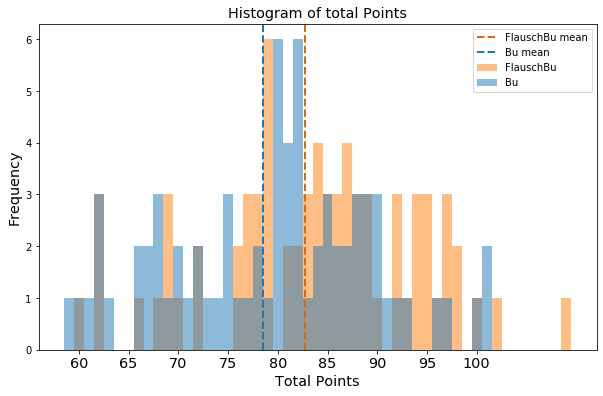

In [7]:
#Plot a histogram of the total points:
fig = plt.figure(figsize = [10,6])
ax1 = fig.add_subplot(1,1,1)

x = np.arange(55,105,5)
ax1.set_xticks(x)
ax1.set_xticklabels(x ,fontsize='x-large')
ax1.set_title("Histogram of total Points",fontsize='x-large')
ax1.set_ylabel("Frequency",fontsize='x-large')
ax1.set_xlabel("Total Points",fontsize='x-large')

Flausch_bins = np.arange(np.min(Flausch_data_totals), np.max(Flausch_data_totals) + 1, 1)
Bu_bins = np.arange(np.min(Data_totals), np.max(Data_totals) + 1, 1)

ax1.hist(Flausch_data_totals, bins = Flausch_bins, alpha = 0.5, align='right', color = "C1", label = "FlauschBu")
ax1.hist(Data_totals, bins = Bu_bins, alpha = 0.5, align='right', color = "C0", label = "Bu")

ax1.axvline(np.mean(Flausch_data_totals),c='chocolate', label="FlauschBu mean", linewidth = 2, linestyle = "dashed")
ax1.axvline(np.mean(Data_totals),c='C0', label="Bu mean", linewidth = 2, linestyle = "dashed")

plt.legend()
plt.plot()

print("Games played:", len(Flausch_data_totals))
print("Mean for FlauschBu:", np.mean(Flausch_data_totals), "+/-", np.std(Flausch_data_totals))
print("Mean for Bu:", np.mean(Data_totals), "+/-", np.std(Data_totals))

### Absolute mean contribution of the individual categories:

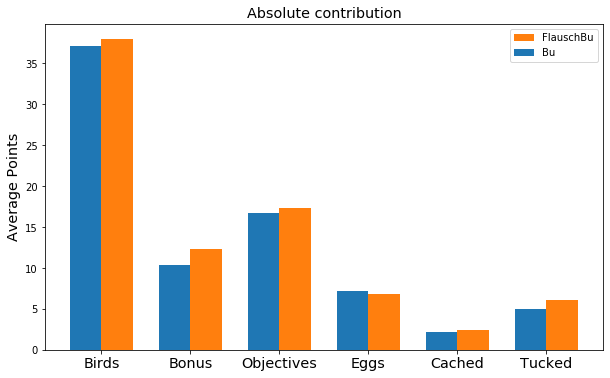

In [8]:
#Compute the mean of each category except for the total number of points ('Total'):

#The category 'Total' is deleted first:
Flausch_bu_means = np.delete((np.mean(Flausch_data_categories, axis = 1)),6)
Bu_means = np.delete(np.mean(Data_categories, axis = 1),6)

labels = ['Birds','Bonus','Objectives','Eggs', 'Cached', 'Tucked']
x = np.arange(1,7,1)
width = 0.35

fig = plt.figure(figsize = [10,6])
ax2 = fig.add_subplot(1,1,1)

ax2.set_xticks(x)
ax2.set_xticklabels(labels ,fontsize='x-large') 
ax2.set_title("Absolute contribution",fontsize='x-large')
ax2.set_ylabel("Average Points",fontsize='x-large')
ax2.bar(x + width/2, Flausch_bu_means, width, label='FlauschBu', color = "C1")
ax2.bar(x - width/2, Bu_means, width, label='Bu', color = "C0")
ax2.legend()

plt.plot()
plt.show()

### Relative mean contribution of the individual categories 
(normalized to the average total points of each Bu):

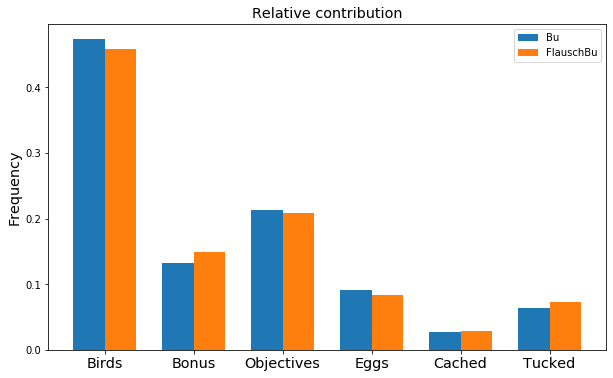

In [9]:
#Same as before but normalized:

Flausch_bu_means = np.delete((np.mean(Flausch_data_categories, axis = 1)/np.mean(Flausch_data_totals)),6)
Bu_means = np.delete(np.mean(Data_categories, axis = 1)/np.mean(Data_totals),6)

labels = ['Birds','Bonus','Objectives','Eggs', 'Cached', 'Tucked']
x = np.arange(1,7,1)
width = 0.35

fig = plt.figure(figsize = [10,6])
ax2 = fig.add_subplot(1,1,1)

ax2.set_xticks(x)
ax2.set_xticklabels(labels ,fontsize='x-large') 
ax2.set_title("Relative contribution",fontsize='x-large')
ax2.set_ylabel("Frequency",fontsize='x-large')
ax2.bar(x - width/2, Bu_means, width, label='Bu',color = "C0")
ax2.bar(x + width/2, Flausch_bu_means, width, label='FlauschBu',color = "C1")
ax2.legend()

plt.plot()
plt.show()

### Games won:

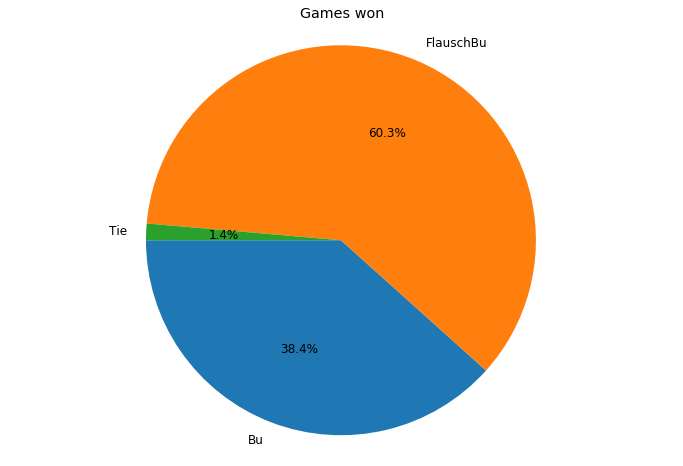

In [10]:
Bu_victories = 0
Flausch_bu_victories = 0
Gleich_bu = 0

#Count how many times each of the Bu's won a game and how often there was a tie:
for i in range(len(Data_totals)):
    if Flausch_data_totals[i] > Data_totals[i]:
        Flausch_bu_victories += 1
    elif Flausch_data_totals[i] == Data_totals[i]:
        Gleich_bu += 1
    else:
        Bu_victories += 1
    
#Define the properties of the pie Chart:
labels = 'Bu', 'FlauschBu', 'Tie'
sizes = [Bu_victories, Flausch_bu_victories, Gleich_bu]

fig = plt.figure(figsize = [12,8])
ax3 = fig.add_subplot(1,1,1)

ax3.set_title("Games won",fontsize='x-large')
ax3.pie(sizes, explode=None, labels=labels, autopct='%1.1f%%',shadow=False, startangle=180, textprops={'fontsize': 12})

ax3.axis('equal')

plt.show()

### Contribution of each categorie:

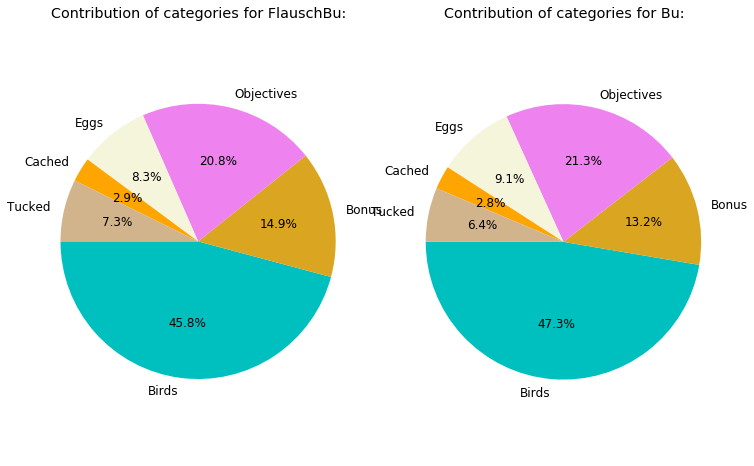

In [11]:
labels = 'Birds', 'Bonus', 'Objectives', 'Eggs', 'Cached', 'Tucked'
colors=('c', 'goldenrod', 'violet', 'beige', 'orange', 'tan')

fig = plt.figure(figsize = [12,8])
ax4 = fig.add_subplot(1,2,1)
ax5 = fig.add_subplot(1,2,2)

ax4.set_title("Contribution of categories for FlauschBu:",fontsize='x-large')
ax5.set_title("Contribution of categories for Bu:",fontsize='x-large')
ax4.pie(Flausch_bu_means, colors = colors, explode=None, labels=labels, autopct='%1.1f%%',shadow=False, startangle=180, textprops={'fontsize': 12})
ax4.axis('equal')
ax5.pie(Bu_means, colors = colors, explode=None, labels=labels, autopct='%1.1f%%',shadow=False, startangle=180, textprops={'fontsize': 12})
ax5.axis('equal')

plt.show()

### Total point time development:

In [12]:
#This gives a time evolution of the mean total points:
#Determine the mean number of total points for a certain amount of games per time span.
#The amount of games included in a time span are chosen with a slider.

#Note that the first 30 games were not documented time ordered, so they are only included for 
#in the analysis for slider value >= 30!

#Create a slider for the interactive plot:
slider = widgets.IntSlider(
    value=5,
    min=1,
    max=len(Flausch_data_totals)/2,
    step=1,
    description='Size',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)


#Pass the widget to the interactive plot (in this case a slider):
def interactive_plot(slider):

    if (slider >= 30):
        #Determine the number of time spans containing a total of 'slider value' games:
        amount_times = int(np.floor(len(Flausch_data_totals)/slider))
        
        #Build an array '..._totals_over_time' with 'amount_times' sub-arrays containing 'slider value' entries of total points:
        #Calculate mean and stddev of each sub array:
        Flausch_totals_over_time = np.zeros((amount_times, slider))
        Flausch_means_over_time = np.zeros(amount_times)
        Flausch_std_over_time = np.zeros(amount_times)

        Totals_over_time = np.zeros((amount_times, slider))
        Means_over_time = np.zeros(amount_times)
        Std_over_time = np.zeros(amount_times)

        i = 0
        j = 1

        for i in range(amount_times):
            Flausch_totals_over_time[i] = Flausch_data_totals[i * slider : j * slider]
            Flausch_means_over_time[i] = np.mean(Flausch_totals_over_time[i])
            Flausch_std_over_time[i] = np.std(Flausch_totals_over_time[i])

            Totals_over_time[i] = Data_totals[i * slider : j * slider]
            Means_over_time[i] = np.mean(Totals_over_time[i])
            Std_over_time[i] = np.std(Totals_over_time[i])
            j += 1


        time_spans = np.arange(0, amount_times, 1)

    else:
        Flausch_data_totals_cut = Flausch_data_totals[30: len(Flausch_data_totals)]
        amount_times = int(np.floor(len(Flausch_data_totals_cut)/slider)) 
        Flausch_totals_over_time = np.zeros((amount_times, slider))
        Flausch_means_over_time = np.zeros(amount_times)
        Flausch_std_over_time = np.zeros(amount_times)

        Totals_over_time = np.zeros((amount_times, slider))
        Means_over_time = np.zeros(amount_times)
        Std_over_time = np.zeros(amount_times)

        i = 0
        j = 1

        for i in range(amount_times):
            Flausch_totals_over_time[i] = Flausch_data_totals[i * slider : j * slider]
            Flausch_means_over_time[i] = np.mean(Flausch_totals_over_time[i])
            Flausch_std_over_time[i] = np.std(Flausch_totals_over_time[i])

            Totals_over_time[i] = Data_totals[i * slider : j * slider]
            Means_over_time[i] = np.mean(Totals_over_time[i])
            Std_over_time[i] = np.std(Totals_over_time[i])
            j += 1


        time_spans = np.arange(0, amount_times, 1)



    fig, ax0 = plt.subplots(1, 1, figsize=(10,8))
    ax0.set_ylabel("Mean of total points",fontsize='x-large') 
    ax0.set_xlabel("Time span",fontsize='x-large') 
    ax0.set_xticks(time_spans)
    ax0.scatter(time_spans, Flausch_means_over_time, label='FlauschBu', color = "C1", marker = "*", linewidths = 1.5)
    ax0.errorbar(time_spans, Flausch_means_over_time, yerr = Flausch_std_over_time, fmt='none', color = "C1")
    ax0.scatter(time_spans, Means_over_time, label='Bu', color = "C0")
    ax0.errorbar(time_spans, Means_over_time, yerr = Std_over_time, fmt='none', color = "C0")
    ax0.legend()

    print(slider, "games in each time span.")
    
control = {'slider' : slider}
display(slider, widgets.interactive_output(interactive_plot, control))



IntSlider(value=5, continuous_update=False, description='Size', max=36, min=1)

Output()

In [13]:
from IPython.display import HTML


HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

